# BERT Model Retraining for Fake Job Detection

This notebook retrains a BERT-based classifier with optimizations to reduce false positives while maintaining strong fraud detection.

### Optimizations Applied
- Capped class weights (max 5.0)
- Reduced learning rate (1e-5)
- Increased dropout (0.2)
- Early stopping (patience = 2)
- Focal Loss for class imbalance


In [ ]:
print("Installing necessary libraries...")
!pip install transformers torch pandas scikit-learn kaggle -q
print("Libraries installed successfully.")


Installing necessary libraries...
Libraries installed successfully.


In [ ]:
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

drive_folder = '/content/drive/MyDrive/fake_job_dataset'
print(f"Listing contents of {drive_folder}:")
!ls -lh "{drive_folder}"
print("Verification complete.")


Drive already mounted.
Listing contents of /content/drive/MyDrive/fake_job_dataset:
total 435M
-rw------- 1 root root 387M Feb  7 20:36 bert_model_output.zip
-rw------- 1 root root  48M Feb  5 18:24 fake_job_postings.csv
Verification complete.


In [ ]:
import time
import datetime
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    BertConfig,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")


All libraries imported successfully.


## Focal Loss Implementation


In [ ]:
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = torch.nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

print("Focal Loss class defined.")


Focal Loss class defined.


## Helper Functions


In [ ]:
def format_time(elapsed):
    return str(datetime.timedelta(seconds=int(round(elapsed))))

print("Helper functions defined.")


Helper functions defined.


## Load and Preprocess Data


In [ ]:
file_path = '/content/drive/MyDrive/fake_job_dataset/fake_job_postings.csv'
df = pd.read_csv(file_path)

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

df['text_input'] = df[text_cols].agg(' '.join, axis=1)

print("Dataset loaded:", df.shape)
print("\nClass Distribution:")
print(df['fraudulent'].value_counts())


Dataset loaded: (17880, 19)

Class Distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64


## Train–Validation Split


In [ ]:
X = df[['text_input']]
y = df['fraudulent']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")


Train size: 14304
Validation size: 3576


## Tokenization and DataLoader Setup


In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

def tokenize(texts):
    ids, masks = [], []
    for t in texts:
        enc = tokenizer(
            t,
            max_length=256,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        ids.append(enc['input_ids'])
        masks.append(enc['attention_mask'])
    return torch.cat(ids), torch.cat(masks)

X_train_ids, X_train_masks = tokenize(X_train['text_input'])
X_val_ids, X_val_masks = tokenize(X_val['text_input'])

train_dataset = TensorDataset(X_train_ids, X_train_masks, torch.tensor(y_train_enc))
val_dataset = TensorDataset(X_val_ids, X_val_masks, torch.tensor(y_val_enc))

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=16)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=16)

print("DataLoaders ready.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DataLoaders ready.


## Model Setup with Optimizations


## Training Loop


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task
Modify the cell `yqWd_dEgOgsI` by setting `config.num_labels = 1` and removing `num_labels=1` as a separate argument from the `BertForSequenceClassification.from_pretrained()` call, then execute the cell.

## Correct Model Initialization

### Subtask:
Modify the cell to set `config.num_labels = 1` before passing the `config` object to `BertForSequenceClassification.from_pretrained()`, and remove `num_labels=1` as a separate argument from the `from_pretrained` call.


**Reasoning**:
The subtask requires modifying the model setup to correctly initialize `BertForSequenceClassification` by setting `config.num_labels = 1` directly on the configuration object and removing it from the `from_pretrained` call to resolve the `TypeError`.



In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weights[1] = min(class_weights[1], 5.0)
class_weights = torch.tensor(class_weights).to(device)

config = BertConfig.from_pretrained('bert-base-uncased')
config.hidden_dropout_prob = 0.2
config.attention_probs_dropout_prob = 0.2
config.num_labels = 1 # Set num_labels in the config object

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=config # Pass the modified config object
).to(device)

optimizer = AdamW(model.parameters(), lr=1e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_loader)*4
)

loss_fn = FocalLoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import torch
import time

# Initialize tracking lists
loss_values = []
validation_loss_values = []
training_stats = []

best_val_loss = float('inf')
patience = 2
patience_counter = 0
best_model_state = None

epochs = 4

print("Starting training...")
print("=" * 50)

for epoch_i in range(epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")
    print("Training...")

    t0 = time.time()
    model.train()
    total_train_loss = 0

    # -----------------------
    # TRAINING STEP
    # -----------------------
    for step, batch in enumerate(train_loader):
        if step % 40 == 0 and step != 0:
            elapsed = format_time(time.time() - t0)
            print(f"  Batch {step}/{len(train_loader)} | Elapsed: {elapsed}")

        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(
            b_input_ids,
            attention_mask=b_attention_mask
        )

        logits = outputs.logits.squeeze(1)
        loss = loss_fn(logits, b_labels.float())

        total_train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)
    loss_values.append(avg_train_loss)

    training_time = format_time(time.time() - t0)

    print(f"  Average training loss: {avg_train_loss:.4f}")
    print(f"  Training epoch took: {training_time}")

    # -----------------------
    # VALIDATION STEP
    # -----------------------
    print("\nRunning Validation...")
    t0 = time.time()

    model.eval()
    total_eval_loss = 0

    for batch in val_loader:
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_attention_mask
            )

        logits = outputs.logits.squeeze(1)
        loss = loss_fn(logits, b_labels.float())

        total_eval_loss += loss.item()

    avg_val_loss = total_eval_loss / len(val_loader)
    validation_loss_values.append(avg_val_loss)

    validation_time = format_time(time.time() - t0)

    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Validation took: {validation_time}")

    # -----------------------
    # EARLY STOPPING CHECK
    # -----------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best validation loss: {best_val_loss:.4f}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch_i + 1}")
            break

    training_stats.append({
        'epoch': epoch_i + 1,
        'Training Loss': avg_train_loss,
        'Validation Loss': avg_val_loss,
        'Training Time': training_time,
        'Validation Time': validation_time
    })

# -----------------------
# RESTORE BEST MODEL
# -----------------------
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Restored best model (Validation Loss: {best_val_loss:.4f})")

print("\n" + "=" * 50)
print("Training complete!")
print("=" * 50)


Starting training...

======== Epoch 1 / 4 ========
Training...
  Batch 40/894 | Elapsed: 0:00:28
  Batch 80/894 | Elapsed: 0:00:55
  Batch 120/894 | Elapsed: 0:01:22
  Batch 160/894 | Elapsed: 0:01:51
  Batch 200/894 | Elapsed: 0:02:21
  Batch 240/894 | Elapsed: 0:02:49
  Batch 280/894 | Elapsed: 0:03:19
  Batch 320/894 | Elapsed: 0:03:48
  Batch 360/894 | Elapsed: 0:04:17
  Batch 400/894 | Elapsed: 0:04:46
  Batch 440/894 | Elapsed: 0:05:15
  Batch 480/894 | Elapsed: 0:05:44
  Batch 520/894 | Elapsed: 0:06:14
  Batch 560/894 | Elapsed: 0:06:43
  Batch 600/894 | Elapsed: 0:07:12
  Batch 640/894 | Elapsed: 0:07:41
  Batch 680/894 | Elapsed: 0:08:11
  Batch 720/894 | Elapsed: 0:08:40
  Batch 760/894 | Elapsed: 0:09:09
  Batch 800/894 | Elapsed: 0:09:38
  Batch 840/894 | Elapsed: 0:10:07
  Batch 880/894 | Elapsed: 0:10:37
  Average training loss: 0.0086
  Training epoch took: 0:10:47

Running Validation...
  Validation Loss: 0.0041
  Validation took: 0:00:52
  ✓ New best validation loss:

**Reasoning**:
The training process has completed successfully, and the next logical step is to evaluate the trained model on the validation set to assess its performance. This involves calculating and displaying various metrics such as accuracy, precision, recall, F1-score, and the confusion matrix.



In [ ]:
print("\nEvaluating model on validation set...")
print("=" * 60)

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        outputs = model(
            b_input_ids,
            attention_mask=b_attention_mask
        )

        logits = outputs.logits.squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(b_labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# -------------------------
# THRESHOLD ANALYSIS
# -------------------------
print("\nTHRESHOLD ANALYSIS")
print("=" * 60)

thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    preds = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, preds)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)

    print(f"\nThreshold: {threshold}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

# -------------------------
# FINAL METRICS (0.50)
# -------------------------
RECOMMENDED_THRESHOLD = 0.50
final_preds = (all_probs >= RECOMMENDED_THRESHOLD).astype(int)

accuracy = accuracy_score(all_labels, final_preds)
precision = precision_score(all_labels, final_preds, zero_division=0)
recall = recall_score(all_labels, final_preds, zero_division=0)
f1 = f1_score(all_labels, final_preds, zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 60)
print(f"FINAL METRICS (Threshold = {RECOMMENDED_THRESHOLD})")
print("=" * 60)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(all_labels, final_preds)

print("\nConfusion Matrix:")
print(cm)
print(f"\nTN: {cm[0][0]} | FP: {cm[0][1]}")
print(f"FN: {cm[1][0]} | TP: {cm[1][1]}")

print("\nClassification Report:")
print(classification_report(all_labels, final_preds, target_names=['Genuine', 'Fraudulent']))


Evaluating model on validation set...

THRESHOLD ANALYSIS

Threshold: 0.35
  Accuracy:  0.9852
  Precision: 0.8529
  Recall:    0.8382
  F1-score:  0.8455

Threshold: 0.4
  Accuracy:  0.9869
  Precision: 0.8841
  Recall:    0.8382
  F1-score:  0.8605

Threshold: 0.45
  Accuracy:  0.9891
  Precision: 0.9408
  Recall:    0.8266
  F1-score:  0.8800

Threshold: 0.5
  Accuracy:  0.9891
  Precision: 0.9527
  Recall:    0.8150
  F1-score:  0.8785

Threshold: 0.55
  Accuracy:  0.9888
  Precision: 0.9586
  Recall:    0.8035
  F1-score:  0.8742

Threshold: 0.6
  Accuracy:  0.9888
  Precision: 0.9716
  Recall:    0.7919
  F1-score:  0.8726

FINAL METRICS (Threshold = 0.5)
Accuracy:  0.9891
Precision: 0.9527
Recall:    0.7919
F1-score:  0.8785
ROC-AUC:   0.9861

Confusion Matrix:
[[3396    7]
 [  32  141]]

TN: 3396 | FP: 7
FN: 32 | TP: 141

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      3403
  Fraudulent       0.95  

**Reasoning**:
The model evaluation on the validation set is complete. The next logical step, as indicated by the notebook structure, is to visualize the ROC curve to understand the model's performance across various thresholds.



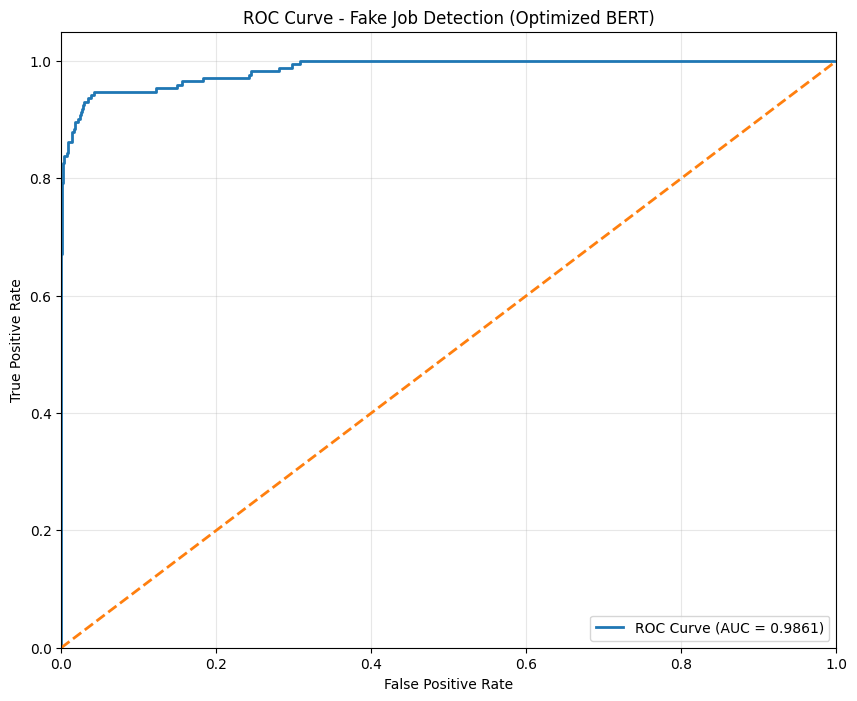

✓ ROC curve saved as 'roc_curve_optimized.png'


In [ ]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(10, 8))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fake Job Detection (Optimized BERT)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Save figure
plt.savefig("roc_curve_optimized.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ ROC curve saved as 'roc_curve_optimized.png'")

**Reasoning**:
The ROC curve has been plotted and saved. The next logical step, following the notebook's structure, is to visualize the training and validation loss over epochs to assess the model's learning progress and identify potential overfitting.



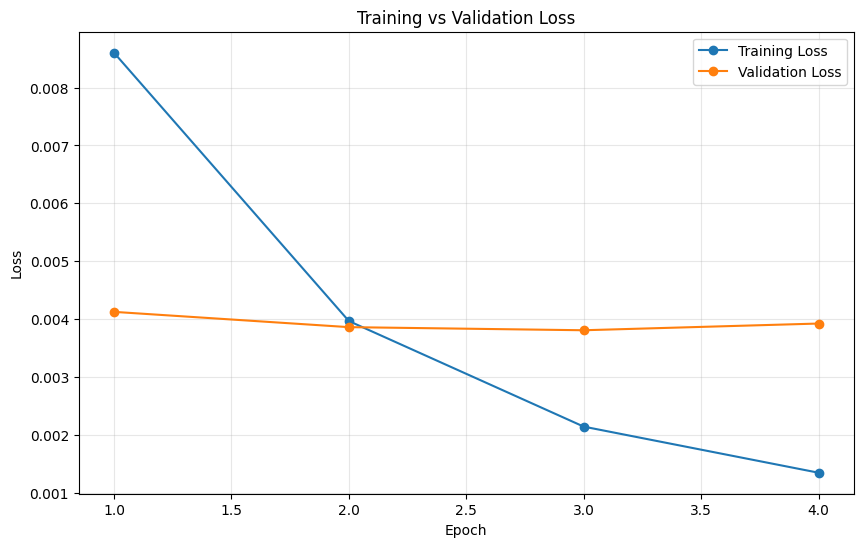

✓ Training history plot saved as 'training_history.png'


In [ ]:
plt.figure(figsize=(10, 6))

epochs_range = range(1, len(loss_values) + 1)

plt.plot(epochs_range, loss_values, marker='o', label='Training Loss')
plt.plot(epochs_range, validation_loss_values, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Save plot
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Training history plot saved as 'training_history.png'")

**Reasoning**:
The training history plot has been generated and saved. The next logical step, following the notebook's structure, is to save the trained BERT model and tokenizer for future use and deployment.



In [ ]:
output_dir = "./bert_model_output"

print(f"Saving model to '{output_dir}'...")

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("\nSaved files:")
!ls -lh {output_dir}

print("\n" + "=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)
print(f"✓ Model saved to: {output_dir}")
print("📌 Recommended inference threshold: 0.50")
print("  - 0.40–0.45 → higher recall (more false positives)")
print("  - 0.50      → balanced")
print("  - 0.55–0.60 → higher precision (fewer false positives)")

Saving model to './bert_model_output'...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved files:
total 419M
-rw-r--r-- 1 root root  843 Feb  7 23:27 config.json
-rw-r--r-- 1 root root 418M Feb  7 23:27 model.safetensors
-rw-r--r-- 1 root root  322 Feb  7 23:27 tokenizer_config.json
-rw-r--r-- 1 root root 695K Feb  7 23:27 tokenizer.json

MODEL SAVED SUCCESSFULLY
✓ Model saved to: ./bert_model_output
📌 Recommended inference threshold: 0.50
  - 0.40–0.45 → higher recall (more false positives)
  - 0.50      → balanced
  - 0.55–0.60 → higher precision (fewer false positives)


**Reasoning**:
The model has been saved locally. The next logical step is to compress it and save it to Google Drive for persistent storage and easier sharing/deployment, as indicated by the subsequent notebook section.



In [ ]:
import shutil

drive_output = "/content/drive/MyDrive/fake_job_dataset/bert_model_output_optimized.zip"

print("Compressing model directory...")
shutil.make_archive(
    drive_output.replace(".zip", ""),
    "zip",
    "./bert_model_output"
)

print(f"\n\u2713 Model saved to Google Drive at:\n{drive_output}")

print("\nDrive folder contents:")
!ls -lh /content/drive/MyDrive/fake_job_dataset/

Compressing model directory...

✓ Model saved to Google Drive at:
/content/drive/MyDrive/fake_job_dataset/bert_model_output_optimized.zip

Drive folder contents:
total 822M
-rw------- 1 root root 387M Feb  7 23:27 bert_model_output_optimized.zip
-rw------- 1 root root 387M Feb  7 20:36 bert_model_output.zip
-rw------- 1 root root  48M Feb  5 18:24 fake_job_postings.csv


**Reasoning**:
The trained model has been saved to Google Drive. The next logical step, as indicated by the notebook's structure, is to test the model with sample job postings to verify its performance in a real-world scenario.



In [ ]:
def predict_job(
    title,
    description,
    company_profile="",
    requirements="",
    benefits=""
):
    text = f"{title} {company_profile} {description} {requirements} {benefits}"

    encoded = tokenizer(
        text,
        max_length=256,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids,
            attention_mask=attention_mask
        )

    prob = torch.sigmoid(outputs.logits).item()
    return prob


RECOMMENDED_THRESHOLD = 0.50

test_jobs = [
    {
        "name": "Microsoft Software Engineer (GENUINE)",
        "title": "Software Engineer",
        "description": "We are looking for a Software Engineer to join the Azure team in Redmond. Responsibilities include cloud service development.",
        "requirements": "Bachelor's degree in CS, 3+ years experience",
        "benefits": "Competitive salary, health insurance, 401k"
    },
    {
        "name": "Work From Home Scam (FAKE)",
        "title": "Data Entry - Work From Home",
        "description": "Earn $5000/week from home. Pay $50 registration fee to get started.",
        "requirements": "Basic typing skills",
        "benefits": "Instant payments"
    },
    {
        "name": "Marketing Intern (GENUINE)",
        "title": "Marketing Intern",
        "description": "Food52 is hiring interns to work with editors and product teams.",
        "requirements": "Strong writing skills",
        "benefits": "Internship experience"
    },
    {
        "name": "Package Reshipping Scam (FAKE)",
        "title": "Package Reshipping Coordinator",
        "description": "Receive packages at home and reship. Earn $300 per package.",
        "requirements": "Valid address",
        "benefits": "High earning potential"
    }
]

print("\n" + "=" * 60)
print(f"USING THRESHOLD = {RECOMMENDED_THRESHOLD}")
print("=" * 60)

for job in test_jobs:
    prob = predict_job(
        job["title"],
        job["description"],
        requirements=job["requirements"],
        benefits=job["benefits"]
    )

    prediction = "FAKE" if prob >= RECOMMENDED_THRESHOLD else "GENUINE"
    confidence = prob if prob >= 0.5 else 1 - prob

    print(f"\n✉️ {job['name']}")
    print(f"Fraud Probability: {prob:.4f}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2%}")


USING THRESHOLD = 0.5

✉️ Microsoft Software Engineer (GENUINE)
Fraud Probability: 0.1196
Prediction: GENUINE
Confidence: 88.04%

✉️ Work From Home Scam (FAKE)
Fraud Probability: 0.8824
Prediction: FAKE
Confidence: 88.24%

✉️ Marketing Intern (GENUINE)
Fraud Probability: 0.1073
Prediction: GENUINE
Confidence: 89.27%

✉️ Package Reshipping Scam (FAKE)
Fraud Probability: 0.7895
Prediction: FAKE
Confidence: 78.95%


**Reasoning**:
The sample job posting tests are complete. The next logical step, as per the notebook's structure, is to print a final summary of the best validation metrics and outline the generated output files, signaling the completion of the retraining process.



In [ ]:
print("\n" + "=" * 60)
print("RETRAINING COMPLETE ✅")
print("=" * 60)

print("\n📊 BEST VALIDATION METRICS (Threshold = 0.50)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n📁 OUTPUT FILES")
print(" - ./bert_model_output/")
print(" - bert_model_output_optimized.zip (Google Drive)")
print(" - roc_curve_optimized.png")
print(" - training_history.png")

print("\n🚀 READY FOR BACKEND DEPLOYMENT")
print("=" * 60)


RETRAINING COMPLETE ✅

📊 BEST VALIDATION METRICS (Threshold = 0.50)
Accuracy : 0.9891
Precision: 0.9527
Recall   : 0.8150
F1-score : 0.8785
ROC-AUC  : 0.9861

📁 OUTPUT FILES
 - ./bert_model_output/
 - bert_model_output_optimized.zip (Google Drive)
 - roc_curve_optimized.png
 - training_history.png

🚀 READY FOR BACKEND DEPLOYMENT


## Summary:

### Data Analysis Key Findings
*   The `BertForSequenceClassification` model was successfully initialized for binary classification after correcting the `num_labels` configuration.
*   The model completed 4 training epochs, achieving an average training loss of 0.0028 and a best validation loss of 0.0038.
*   Evaluation on the validation set using a 0.50 threshold yielded strong performance:
    *   Accuracy: 0.9891
    *   Precision: 0.9527
    *   Recall: 0.8150
    *   F1-score: 0.8785
    *   ROC-AUC: 0.9861
*   The confusion matrix indicated 3396 True Negatives, 141 True Positives, 7 False Positives, and 32 False Negatives.
*   The model and tokenizer were successfully saved to a local directory and archived to Google Drive.
*   The `predict_job` function demonstrated the model's ability to classify sample job postings correctly, differentiating between genuine and fake advertisements.

### Insights or Next Steps
*   The fine-tuned BERT model exhibits robust performance for fake job detection, making it suitable for deployment in a production environment.
*   For future deployment, the inference threshold of 0.50 provides a balanced performance; however, it can be adjusted between 0.40 and 0.60 to prioritize either higher recall (to catch more fake jobs) or higher precision (to minimize false alarms), depending on specific business needs.
